# Spell-level survival — Cox & AFT

The persistence notebook modelled survival *block by block* (duration-so-far is a valid regressor).
Cox and AFT take the **spell** as the unit and model its whole length, so here **duration is the
outcome / time axis, never a regressor** — feeding `spell_duration` back in would be circular.

## The dataframe these models need — one row per spell

| column | role | measured at |
|---|---|---|
| `duration` | **time axis** (outcome) | spell length in blocks |
| `event` | censoring flag | `1` = closure observed, `0` = right-censored |
| `log_base_fee`, `gas_util`, `tip_p90`, `mev_intensity`, `freq`, `dlogL` | baseline covariates | **`onset_block − 1`** (block *before* onset) |
| `log_vol` | baseline covariate | **`onset_block`** (already backward-looking) |
| ~~`spell_duration`~~ | — | **excluded** (it *is* the outcome) |

The trading-shaped covariates are taken at **onset − 1** (predetermined, the spell-level analogue of
the block `_lag`); `log_vol` at onset since `ewma_vol` is already backward-looking. Built from the
full panel (the closure set excludes every spell's own onset block); left-truncated spells are
dropped. All logic lives in `arblib.estimation`.

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter, WeibullAFTFitter

from arblib import estimation as est
from arblib.config import STUDY as S

panel = est.load_panel(S)
print("panel:", panel.shape)

panel: (4704, 28)


## Spell-level survival sample

`build_survival_sample` anchors each baseline covariate at the block described above; `spell_duration`
is not carried.

In [2]:
surv = est.build_survival_sample(panel, quantile=0.2)
surv.head()

spells: 39 | closed: 36 | censored: 3 | left-truncated: 0 | median duration: 2.0
survival: 39 spells from 39 | events: 36 | pairs: 6 | dropped 0 left-truncated | dropped 0 with undefined pre-onset covariate


,spell_id,pair,onset_block,duration,event,log_base_fee,gas_util,tip_p90,mev_intensity,freq,log_vol,dlogL,left_truncated
0,pancake_1_vs_pancake_2_q20_1,pancake_1_vs_pancake_2,24132166,2,0,18.125932,0.148569,21.416413,17.941542,0.211311,-8.347687,0.000000,False
1,uniswap_1_vs_pancake_1_q20_1,uniswap_1_vs_pancake_1,24131948,4,1,17.978871,0.353688,21.410623,18.573351,0.483370,-8.452673,0.000000,False
2,uniswap_1_vs_pancake_1_q20_3,uniswap_1_vs_pancake_1,24131953,1,1,17.865073,0.889276,21.197044,18.575605,0.556979,-8.469234,0.000000,False
3,uniswap_1_vs_pancake_1_q20_5,uniswap_1_vs_pancake_1,24131960,1,1,17.856488,0.977256,21.416413,18.689187,0.570174,-8.467187,0.000000,False
4,uniswap_1_vs_pancake_1_q20_7,uniswap_1_vs_pancake_1,24131971,1,1,17.867563,0.340391,21.403290,19.051606,0.797848,-8.483917,-0.003869,False


## Cox proportional-hazards model

Models the closure hazard on the baseline covariates (`exp(coef)` = hazard ratio, `>1` = faster
closure). SEs clustered by pool pair. `duration` enters only as the time axis.

concordance: 0.786


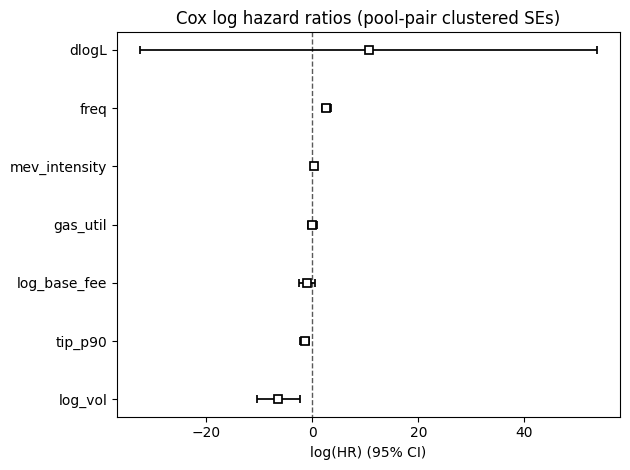

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
log_base_fee,-0.972624,0.378090,0.778732,-2.498910,0.553663,8.217455e-02,1.739613e+00,0.0,-1.248984,2.116709e-01,2.240105
gas_util,-0.034065,0.966509,0.432279,-0.881316,0.813187,4.142373e-01,2.255083e+00,0.0,-0.078803,9.371896e-01,0.093587
tip_p90,-1.486143,0.226244,0.467733,-2.402882,-0.569404,9.045690e-02,5.658628e-01,0.0,-3.177334,1.486357e-03,9.394004
mev_intensity,0.290358,1.336906,0.211905,-0.124969,0.705685,8.825244e-01,2.025233e+00,0.0,1.370225,1.706167e-01,2.551169
freq,2.616796,13.691782,0.411163,1.810931,3.422661,6.116139e+00,3.065086e+01,0.0,6.364375,1.960867e-10,32.247790
log_vol,-6.413766,0.001639,2.058833,-10.449004,-2.378527,2.897712e-05,9.268697e-02,0.0,-3.115243,1.837932e-03,9.087701
dlogL,10.589340,39709.271407,21.998714,-32.527348,53.706028,7.473987e-15,2.109753e+23,0.0,0.481362,6.302594e-01,0.665982


In [3]:
cox = CoxPHFitter()
cox.fit(surv[["duration", "event", "pair"] + est.SURVIVAL_TERMS],
        duration_col="duration", event_col="event", cluster_col="pair", robust=True)

print("concordance:", round(cox.concordance_index_, 3))
cox.plot(); plt.title("Cox log hazard ratios (pool-pair clustered SEs)"); plt.tight_layout(); plt.show()
cox.summary

## Weibull AFT model

The accelerated-failure-time complement: models log survival time directly, so `exp(coef)` on the
`lambda_` params is a *time* ratio (`>1` = longer spells). A robustness on the proportional-hazards
assumption.

In [4]:
aft = WeibullAFTFitter()
aft.fit(surv[["duration", "event"] + est.SURVIVAL_TERMS], duration_col="duration", event_col="event")

print("median survival (blocks):", round(aft.median_survival_time_, 2),
      "| concordance:", round(aft.concordance_index_, 3))
aft.summary

median survival (blocks): 2.24 | concordance: 0.782


coef      exp(coef)   se(coef)  coef lower 95%  \
param   covariate                                                            
lambda_ dlogL           3.439358      31.166958  21.679613      -39.051903   
        freq           -1.198530       0.301637   0.535375       -2.247845   
        gas_util        0.088313       1.092330   0.422451       -0.739677   
        log_base_fee    0.084726       1.088419   0.736303       -1.358402   
        log_vol         3.015244      20.394061   0.898234        1.254738   
        mev_intensity  -0.114241       0.892043   0.112959       -0.335636   
        tip_p90         0.662965       1.940538   0.248299        0.176307   
        Intercept      13.281135  586035.377898  20.035554      -25.987829   
rho_    Intercept       0.918409       2.505302   0.130626        0.662387   

                       coef upper 95%  exp(coef) lower 95%  \
param   covariate                                            
lambda_ dlogL               45.930620         1.096413e-17   
        freq                -0.149215         1.056266e-01   
        gas_util             0.916303         4.772682e-01   
        log_base_fee         1.527853         2.570713e-01   
        log_vol              4.775749         3.506920e+00   
        mev_intensity        0.107154         7.148836e-01   
        tip_p90              1.149623         1.192804e+00   
        Intercept           52.550100         5.171652e-12   
rho_    Intercept            1.174431         1.939417e+00   

                       exp(coef) upper 95%  cmp to         z             p  \
param   covariate                                                            
lambda_ dlogL                 8.859614e+19     0.0  0.158645  8.739487e-01   
        freq                  8.613842e-01     0.0 -2.238675  2.517708e-02   
        gas_util              2.500030e+00     0.0  0.209049  8.344101e-01   
        log_base_fee          4.608274e+00     0.0  0.115069  9.083903e-01   
        log_vol               1.185992e+02     0.0  3.356859  7.883332e-04   
        mev_intensity         1.113106e+00     0.0 -1.011350  3.118489e-01   
        tip_p90               3.157003e+00     0.0  2.670022  7.584630e-03   
        Intercept             6.640769e+22     0.0  0.662878  5.074085e-01   
rho_    Intercept             3.236302e+00     0.0  7.030841  2.052919e-12   

                        -log2(p)  
param   covariate                 
lambda_ dlogL           0.194379  
        freq            5.311745  
        gas_util        0.261171  
        log_base_fee    0.138616  
        log_vol        10.308907  
        mev_intensity   1.681081  
        tip_p90         7.042705  
        Intercept       0.978781  
rho_    Intercept      38.825460